# SHAP Model Explanation

This notebook explains the saved restaurant-feasibility model with global SHAP plots. It creates:

- a bar summary plot (mean absolute SHAP impact);
- a beeswarm plot (impact and direction for individual rows);
- dependence plots for the four grouped numeric factors.

The notebook only reads the saved model and dataset. It does not retrain or overwrite the application model. Positive SHAP values move the model toward the selected class; negative values move it away.

In [25]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

RANDOM_STATE = 42
BACKGROUND_SIZE = 100
EXPLANATION_SIZE = 500
TARGET_CLASS = "High"  # Choose: "Low", "Moderate", or "High"

def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "backend" / "models").exists() and (candidate / "data" / "processed").exists():
            return candidate
        nested = candidate / "minor_prj"
        if (nested / "backend" / "models").exists() and (nested / "data" / "processed").exists():
            return nested
    raise FileNotFoundError("Run this notebook from minor_prj/notebooks or the repository root.")

PROJECT_ROOT = find_project_root()
MODEL_PATH = PROJECT_ROOT / "backend" / "models" / "restaurant_feasibility_pipeline.joblib"
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_final_entropy.csv"
OUTPUT_DIRECTORY = PROJECT_ROOT / "outputs" / "shap"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Model:   {MODEL_PATH}")
print(f"Dataset: {DATASET_PATH}")
print(f"Plots:   {OUTPUT_DIRECTORY}")

Model:   c:\Users\mausa\Desktop\grouping_approach\minor_prj\backend\models\restaurant_feasibility_pipeline.joblib
Dataset: c:\Users\mausa\Desktop\grouping_approach\minor_prj\data\processed\dataset_final_entropy.csv
Plots:   c:\Users\mausa\Desktop\grouping_approach\minor_prj\outputs\shap


## Load the fitted pipeline and analysis data

SHAP must receive data after the same fitted preprocessing used by the classifier. The saved pipeline remains the source of truth for feature names and class ordering.

In [26]:
model_package = joblib.load(MODEL_PATH)
model_pipeline = model_package["pipeline"] if isinstance(model_package, dict) else model_package
metadata = model_package.get("metadata", {}) if isinstance(model_package, dict) else {}

model_features = metadata.get("model_features") or list(model_pipeline.feature_names_in_)
preprocessor = model_pipeline.named_steps["preprocessor"]
classifier = model_pipeline.named_steps["classifier"]
label_mapping = metadata.get("label_mapping", {})
label_mapping = {int(key): value for key, value in label_mapping.items()}

dataset = pd.read_csv(DATASET_PATH)
missing_features = sorted(set(model_features) - set(dataset.columns))
if missing_features:
    raise ValueError(f"Dataset is missing model features: {missing_features}")

model_data = dataset[model_features].dropna().reset_index(drop=True)
background_frame = model_data.sample(n=min(BACKGROUND_SIZE, len(model_data)), random_state=RANDOM_STATE)
explanation_frame = model_data.sample(n=min(EXPLANATION_SIZE, len(model_data)), random_state=RANDOM_STATE)

background = preprocessor.transform(background_frame)
transformed = preprocessor.transform(explanation_frame)
if hasattr(background, "toarray"):
    background = background.toarray()
if hasattr(transformed, "toarray"):
    transformed = transformed.toarray()

transformed_feature_names = list(preprocessor.get_feature_names_out())
class_labels = [label_mapping.get(int(value), str(value)) for value in classifier.classes_]
if TARGET_CLASS not in class_labels:
    raise ValueError(f"TARGET_CLASS must be one of {class_labels}")
class_index = class_labels.index(TARGET_CLASS)

print(f"Model: {metadata.get('model_name', type(classifier).__name__)}")
print(f"Rows explained: {len(explanation_frame)}")
print(f"Available classes: {class_labels}")
print(f"Selected class: {TARGET_CLASS}")

Model: Logistic Regression
Rows explained: 500
Available classes: ['Low', 'Moderate', 'High']
Selected class: High


## Calculate SHAP values

`LinearExplainer` is appropriate because the final fitted classifier is logistic regression. For a multiclass model, SHAP returns a separate explanation for every class; the following cell selects the class configured above.

In [27]:
explainer = shap.LinearExplainer(classifier, background)
all_explanations = explainer(transformed)

if all_explanations.values.ndim == 3:
    class_explanation = all_explanations[:, :, class_index]
elif all_explanations.values.ndim == 2:
    class_explanation = all_explanations
else:
    raise ValueError(f"Unexpected SHAP shape: {all_explanations.values.shape}")

class_explanation.feature_names = transformed_feature_names
print("SHAP values shape:", class_explanation.values.shape)

SHAP values shape: (500, 13)


## Summary bar plot

This ranks features by their average absolute impact. It shows importance magnitude, but not whether a feature moves predictions toward or away from the selected class.

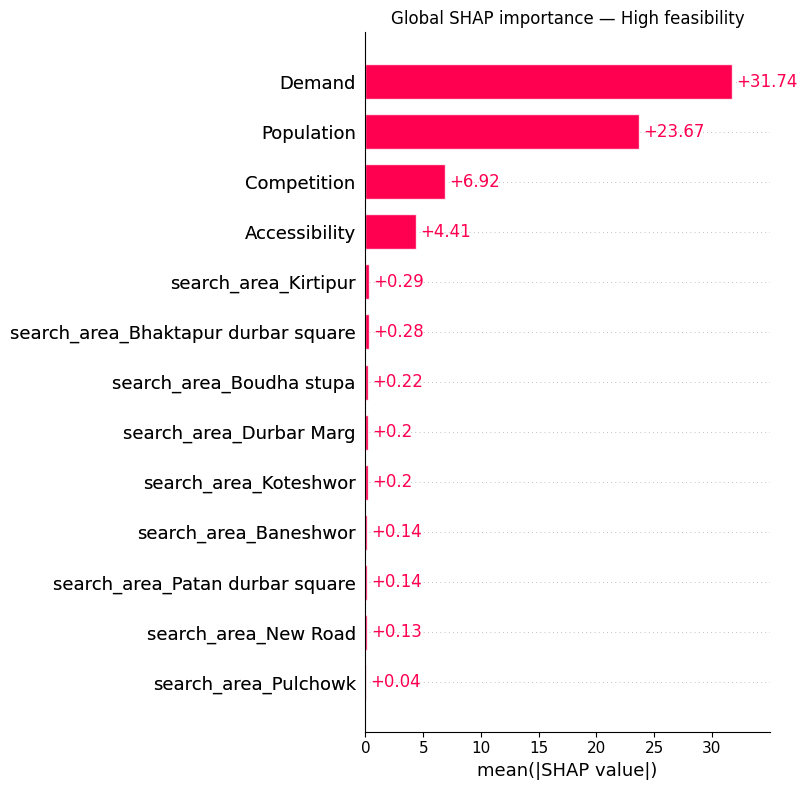

In [28]:
shap.plots.bar(class_explanation, max_display=len(transformed_feature_names), show=False)
plt.title(f"Global SHAP importance — {TARGET_CLASS} feasibility")
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / f"summary_bar_{TARGET_CLASS.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()

## Beeswarm plot

Each dot is one sampled location. Horizontal position is its SHAP impact, while color represents the transformed feature value. Dots to the right support the selected class and dots to the left oppose it.

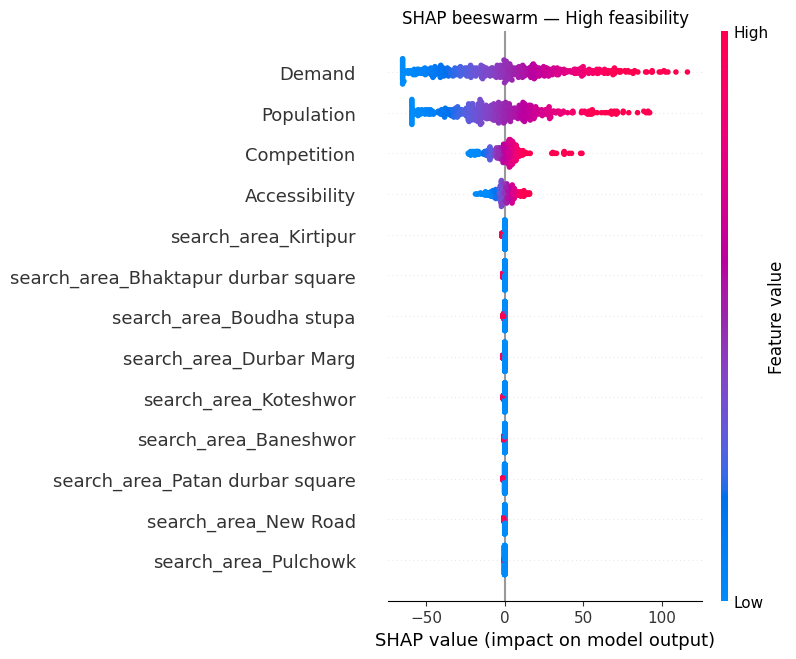

In [29]:
shap.plots.beeswarm(class_explanation, max_display=len(transformed_feature_names), show=False)
plt.title(f"SHAP beeswarm — {TARGET_CLASS} feasibility")
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / f"beeswarm_{TARGET_CLASS.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()

## Dependence plots

These plots show how each grouped factor's original value relates to its SHAP impact. Color indicates the strongest interacting transformed feature selected automatically by SHAP.

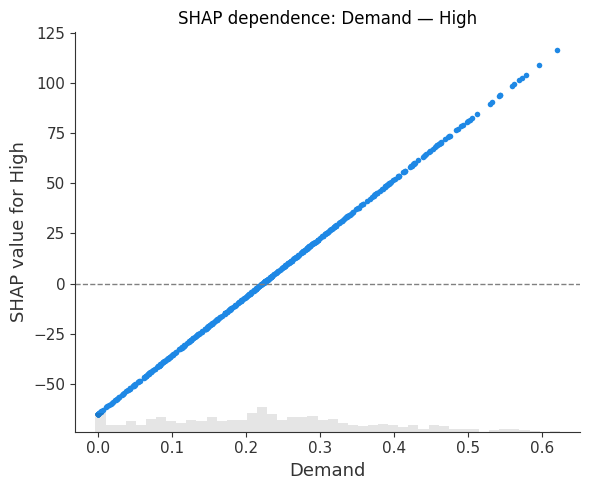

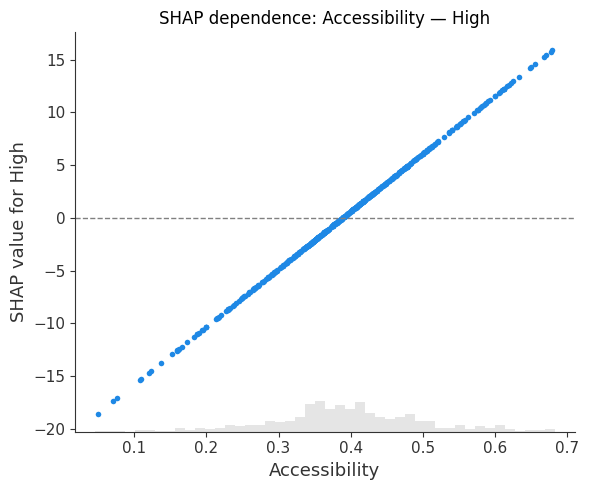

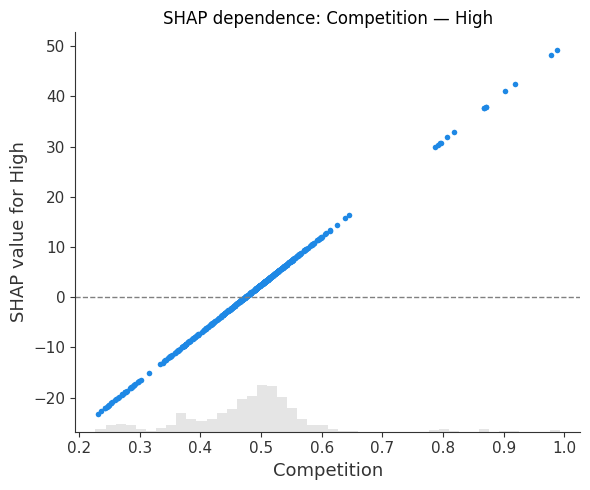

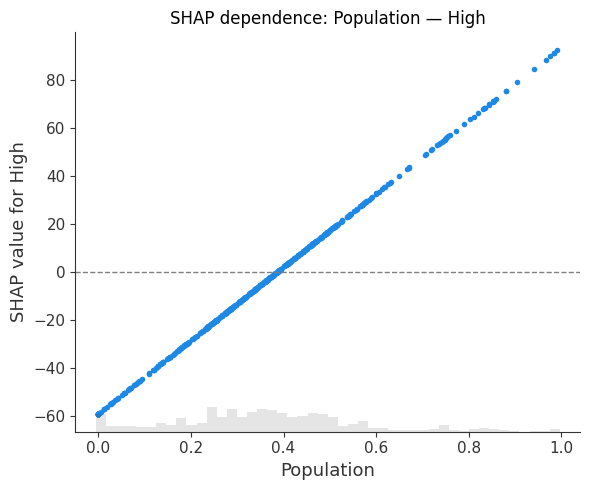

In [30]:
numeric_features = metadata.get("numeric_features", ["Demand", "Accessibility", "Competition", "Population"])

# Use original factor values on the x-axis and the corresponding SHAP values on the y-axis.
for feature in numeric_features:
    feature_index = transformed_feature_names.index(feature)
    dependence_explanation = shap.Explanation(
        values=class_explanation.values[:, feature_index],
        base_values=class_explanation.base_values,
        data=explanation_frame[feature].to_numpy(),
        feature_names=feature,
    )
    shap.plots.scatter(dependence_explanation, show=False)
    plt.axhline(0, color="gray", linewidth=1, linestyle="--")
    plt.title(f"SHAP dependence: {feature} — {TARGET_CLASS}")
    plt.xlabel(feature)
    plt.ylabel(f"SHAP value for {TARGET_CLASS}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRECTORY / f"dependence_{feature.lower()}_{TARGET_CLASS.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Interpretation notes

- SHAP explains associations learned by the fitted model; it does not establish causation.
- Importance is class-specific. Change `TARGET_CLASS` and rerun all cells to inspect another class.
- `search_area_*` columns are one-hot encoded categories created by preprocessing.
- The plots use a reproducible sample to remain fast. Increase `EXPLANATION_SIZE` if a larger analysis is needed.
- Generated PNG files are saved under `minor_prj/outputs/shap`.